# 🎯 Clustering Algorithms — Complete Interview Prep Notebook

**Covers:** K-Means, Hierarchical, DBSCAN, GMM, Spectral Clustering  
**Includes:** Theory, Math, Python Code, Visualizations, Interview Q&A

---

## 📑 Table of Contents

1. [Setup & Imports](#1.-Setup-&-Imports)
2. [What is Clustering?](#2.-What-is-Clustering?)
3. [K-Means Algorithm](#3.-K-Means-Algorithm)
4. [Choosing K & scikit-learn](#4.-Choosing-K-&-scikit-learn)
5. [Hierarchical Clustering](#5.-Hierarchical-Clustering)
6. [DBSCAN](#6.-DBSCAN)
7. [Gaussian Mixture Models (GMM)](#7.-Gaussian-Mixture-Models-(GMM))
8. [Spectral Clustering](#8.-Spectral-Clustering)
9. [Evaluation Metrics](#9.-Evaluation-Metrics)
10. [Algorithm Comparison](#10.-Algorithm-Comparison)
11. [Challenging Datasets & Edge Cases](#11.-Challenging-Datasets-&-Edge-Cases)
12. [Interview Questions & Answers](#12.-Interview-Questions-&-Answers)


---
## 1. Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    adjusted_rand_score, normalized_mutual_info_score,
    davies_bouldin_score, calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

COLORS = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6',
          '#1ABC9C', '#E67E22', '#34495E', '#E91E63', '#00BCD4']
CMAP = ListedColormap(COLORS)

print('✅ All imports successful!')

✅ All imports successful!


---
## 2. What is Clustering?

Clustering is an **unsupervised learning** technique that groups data points into subsets (clusters) such that:
- Points **within** a cluster are highly similar to each other
- Points **across** different clusters are dissimilar

### Types of Clustering

| Type | Description | Examples |
|------|-------------|----------|
| **Partitional** | Non-overlapping subsets | K-Means, K-Medoids |
| **Hierarchical** | Tree of nested clusters | Agglomerative, Divisive |
| **Density-based** | Clusters = dense regions | DBSCAN, OPTICS, HDBSCAN |
| **Model-based** | Mixture of distributions | GMM, Bayesian GMM |
| **Spectral** | Graph-based via eigenvalues | Spectral Clustering |

### Applications
Customer segmentation, anomaly detection, image segmentation, document grouping, gene expression analysis, recommendation systems, social network analysis.

### Key Distance Metrics

| Metric | Formula | Use Case |
|--------|---------|----------|
| **Euclidean** | $\sqrt{\sum(x_i - y_i)^2}$ | Continuous, spherical clusters |
| **Manhattan** | $\sum|x_i - y_i|$ | Grid-like data, robust to outliers |
| **Cosine** | $1 - \frac{x \cdot y}{\|x\|\|y\|}$ | Text, high-dimensional sparse data |
| **Mahalanobis** | $\sqrt{(x-y)^T S^{-1} (x-y)}$ | Correlated features |

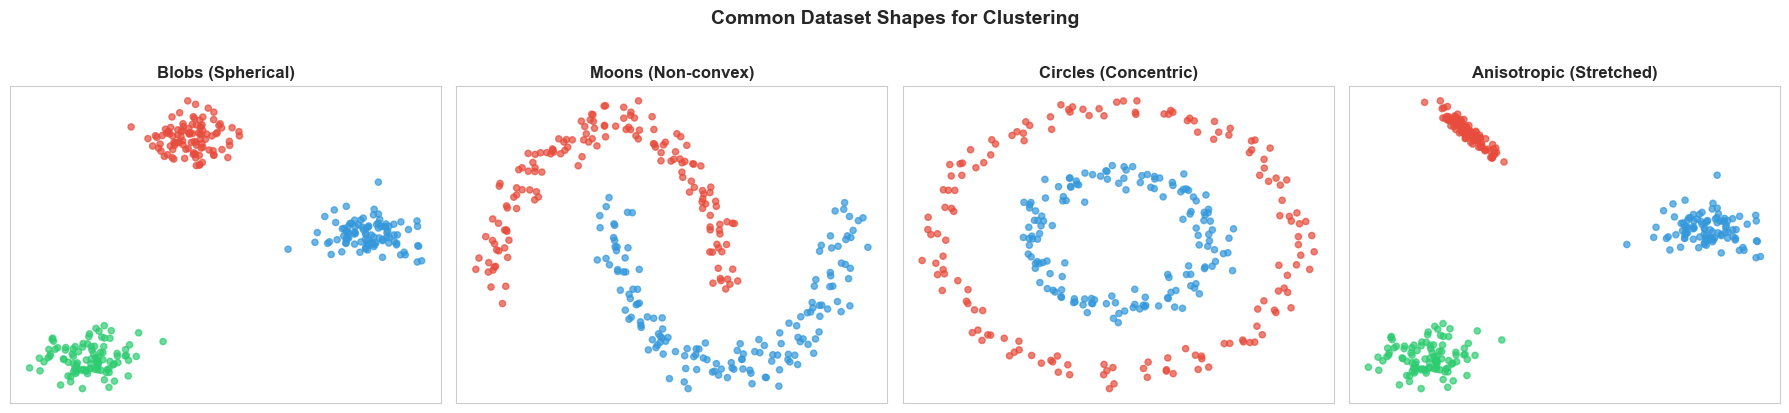

In [2]:
# Generate sample datasets for visualization
np.random.seed(42)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Blobs (good for K-Means)
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=[COLORS[i] for i in y_blobs], s=20, alpha=0.7)
axes[0].set_title('Blobs (Spherical)', fontweight='bold')

# Moons (non-convex)
X_moons, y_moons = make_moons(n_samples=300, noise=0.07, random_state=42)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=[COLORS[i] for i in y_moons], s=20, alpha=0.7)
axes[1].set_title('Moons (Non-convex)', fontweight='bold')

# Circles
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)
axes[2].scatter(X_circles[:, 0], X_circles[:, 1], c=[COLORS[i] for i in y_circles], s=20, alpha=0.7)
axes[2].set_title('Circles (Concentric)', fontweight='bold')

# Anisotropic
X_aniso = np.dot(X_blobs[y_blobs == 0], [[0.6, -0.6], [-0.4, 0.8]])
X_aniso = np.vstack([X_aniso, X_blobs[y_blobs == 1], X_blobs[y_blobs == 2]])
y_aniso = np.hstack([np.zeros(100), np.ones(100), np.full(100, 2)]).astype(int)
axes[3].scatter(X_aniso[:, 0], X_aniso[:, 1], c=[COLORS[i] for i in y_aniso], s=20, alpha=0.7)
axes[3].set_title('Anisotropic (Stretched)', fontweight='bold')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('Common Dataset Shapes for Clustering', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. K-Means Algorithm

### The simple idea

Imagine you have a room full of people and you want to split them into K groups based on where they're standing.

1. **Drop K flags** randomly on the floor — these are your initial cluster centers (centroids).
2. **Everyone walks** to the nearest flag. Now you have K groups.
3. **Move each flag** to the middle of its group (the average position of everyone who walked to it).
4. **Repeat** steps 2–3. People might switch groups as flags move. Eventually the flags stop moving — that's convergence.

That's it. K-Means is just: *assign to nearest center → recalculate centers → repeat.*

The algorithm tries to minimize the total distance between each person and their flag. In math, this total distance is called **inertia** (or WCSS — within-cluster sum of squares).

### Formal algorithm (Lloyd's)

1. **Initialize** K centroids $\mu_1, \mu_2, \dots, \mu_K$
2. **Assign** each point to the nearest centroid: $c_i = \arg\min_k \|x_i - \mu_k\|^2$
3. **Update** each centroid to the mean of its assigned points: $\mu_k = \frac{1}{|C_k|} \sum_{x \in C_k} x$
4. **Repeat** steps 2–3 until assignments stop changing

### The math behind it

**Objective function** — K-Means minimizes:

$$J = \sum_{k=1}^{K} \sum_{x \in C_k} \|x - \mu_k\|^2$$

Why does updating the centroid to the mean work? Because taking $\frac{\partial J}{\partial \mu_k} = 0$ gives us exactly the mean:

$$\mu_k = \frac{1}{|C_k|} \sum_{x \in C_k} x$$

**Why it converges:** Each assignment step can only decrease (or maintain) $J$ — every point moves to a closer centroid. Each update step also can only decrease $J$ — the mean minimizes squared distances. Since $J \geq 0$ and it's always going down, it must converge. But beware: it converges to a **local minimum**, not necessarily the global one. That's why we run it multiple times (`n_init`).

**Complexity:** $O(n \cdot K \cdot d \cdot I)$ — with $n$ points, $K$ clusters, $d$ dimensions, $I$ iterations.

### K-Means++ initialization

Random initialization can lead to bad results. K-Means++ fixes this by spreading initial centroids apart: each new centroid is chosen with probability proportional to $D(x)^2$ (squared distance to nearest existing centroid). This makes convergence faster and more reliable.

### Connection to EM / GMM

K-Means is actually a **special case of Gaussian Mixture Models** where all clusters are spherical with equal variance, and assignments are hard (0 or 1) instead of soft (probabilities). As $\sigma \to 0$, EM reduces to K-Means.

### Strengths & weaknesses

| ✅ Strengths | ❌ Weaknesses |
|-------------|---------------|
| Simple and intuitive | Must specify K in advance |
| Very fast and scalable | Assumes spherical, equal-sized clusters |
| Guaranteed to converge | Sensitive to outliers |
| Works well on large datasets | Converges to local minimum (non-deterministic) |

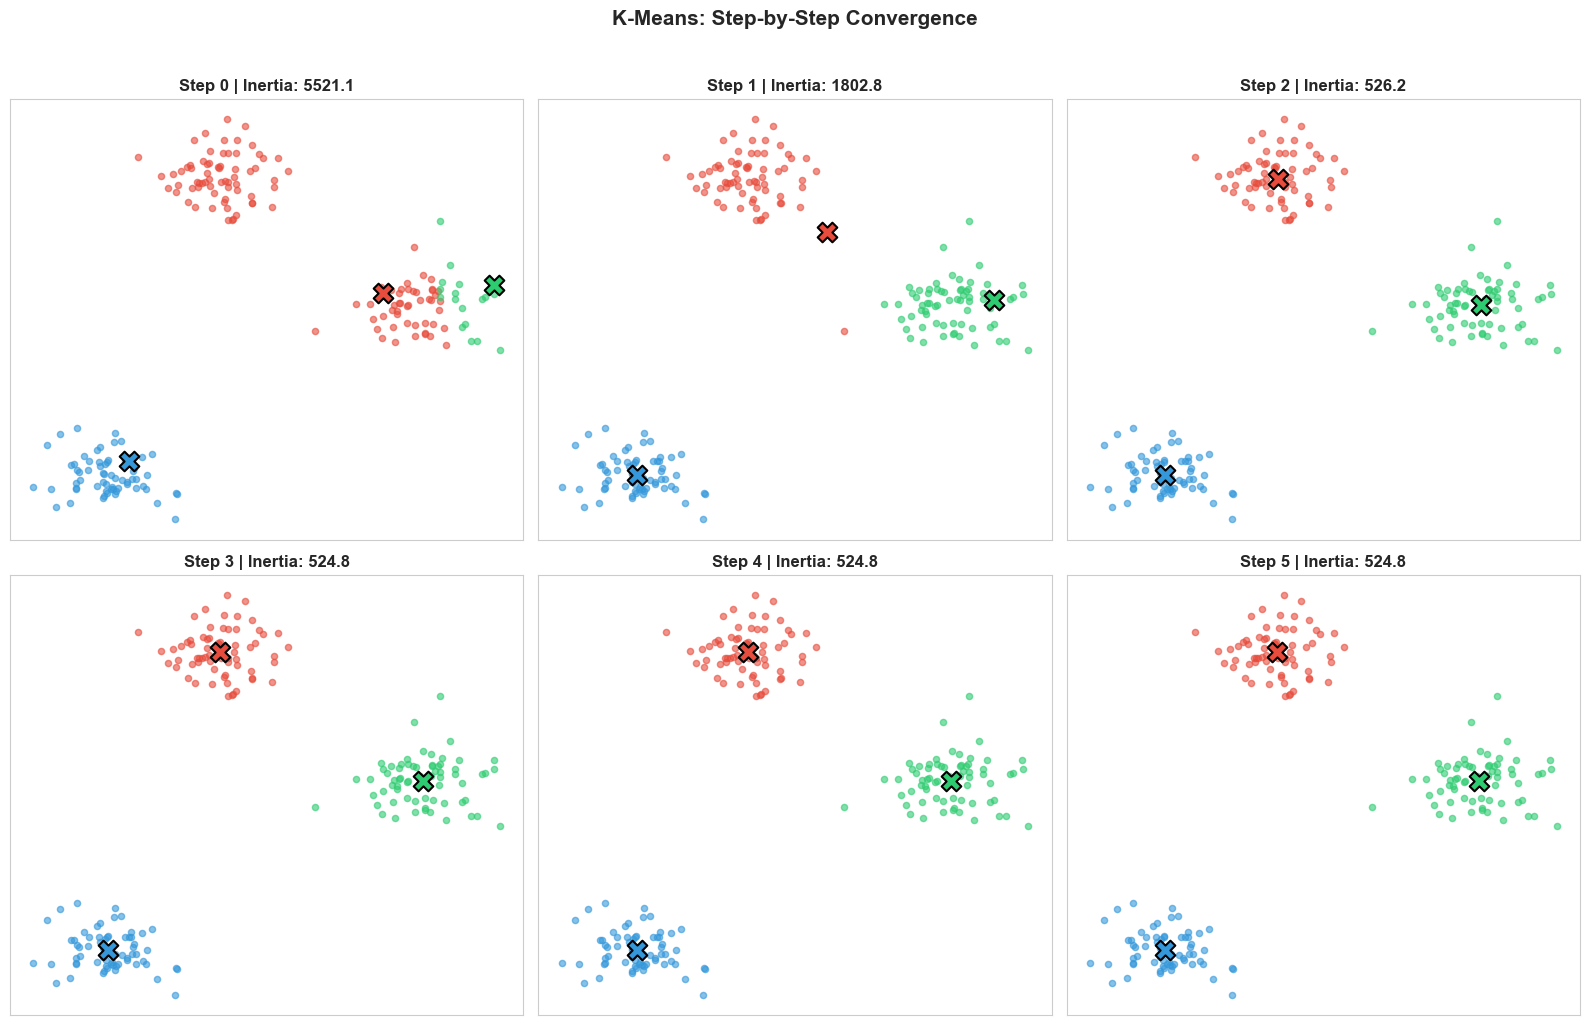

In [3]:
# Visualize K-Means step by step — watch the centroids (X markers) converge
np.random.seed(42)
X, y_true = make_blobs(n_samples=200, centers=3, cluster_std=1.2, random_state=42)

K = 3
rng = np.random.RandomState(10)
centroids = X[rng.choice(len(X), K, replace=False)]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for step in range(6):
    ax = axes[step]
    
    # Assignment step: each point goes to nearest centroid
    distances = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)
    labels = np.argmin(distances, axis=1)
    
    for k in range(K):
        mask = labels == k
        ax.scatter(X[mask, 0], X[mask, 1], c=COLORS[k], s=20, alpha=0.6)
        ax.scatter(centroids[k, 0], centroids[k, 1], c=COLORS[k], s=200,
                   marker='X', edgecolors='black', linewidths=1.5, zorder=5)
    
    inertia = sum(np.sum((X[labels == k] - centroids[k])**2) for k in range(K))
    ax.set_title(f'Step {step} | Inertia: {inertia:.1f}', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    
    # Update step: move centroids to the mean of their group
    centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])

plt.suptitle('K-Means: Step-by-Step Convergence', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Implementation from scratch

Below is a clean NumPy implementation with K-Means++ init — great for understanding the internals and a common interview ask.

Converged in 2 iterations
Inertia: 18.2632
Silhouette Score: 0.8482


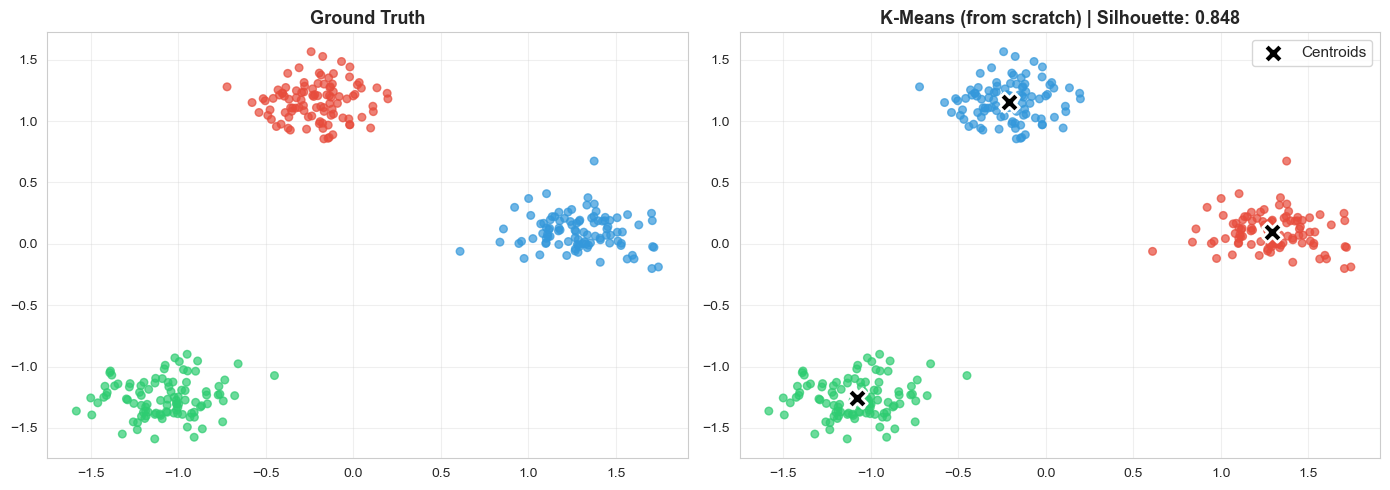

In [4]:
class KMeansFromScratch:
    """K-Means with K-Means++ initialization, built from scratch."""
    
    def __init__(self, n_clusters=3, max_iter=300, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
    
    def _init_centroids_pp(self, X):
        """K-Means++ initialization: spread centroids apart."""
        rng = np.random.RandomState(self.random_state)
        n = X.shape[0]
        centroids = [X[rng.randint(n)]]
        for _ in range(1, self.n_clusters):
            dists = np.min([np.sum((X - c)**2, axis=1) for c in centroids], axis=0)
            centroids.append(X[rng.choice(n, p=dists / dists.sum())])
        return np.array(centroids)
    
    def fit(self, X):
        self.centroids_ = self._init_centroids_pp(X)
        
        for i in range(self.max_iter):
            # Assign each point to nearest centroid
            distances = np.linalg.norm(X[:, None] - self.centroids_[None, :], axis=2)
            self.labels_ = np.argmin(distances, axis=1)
            
            # Update centroids to cluster means
            new_centroids = np.array([
                X[self.labels_ == k].mean(axis=0) if (self.labels_ == k).any()
                else self.centroids_[k]
                for k in range(self.n_clusters)
            ])
            
            # Check convergence
            if np.linalg.norm(new_centroids - self.centroids_) < self.tol:
                self.n_iter_ = i + 1
                break
            self.centroids_ = new_centroids
        else:
            self.n_iter_ = self.max_iter
        
        self.inertia_ = sum(np.sum((X[self.labels_ == k] - self.centroids_[k])**2)
                           for k in range(self.n_clusters))
        return self
    
    def predict(self, X):
        return np.argmin(np.linalg.norm(X[:, None] - self.centroids_[None, :], axis=2), axis=1)


# Test: our implementation vs ground truth
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

km = KMeansFromScratch(n_clusters=3)
km.fit(X_scaled)

print(f'Converged in {km.n_iter_} iterations')
print(f'Inertia: {km.inertia_:.4f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, km.labels_):.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], c=[COLORS[i] for i in y_true], s=30, alpha=0.7)
ax1.set_title('Ground Truth', fontweight='bold', fontsize=13)

ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=[COLORS[i] for i in km.labels_], s=30, alpha=0.7)
ax2.scatter(km.centroids_[:, 0], km.centroids_[:, 1], c='black', s=200,
           marker='X', edgecolors='white', linewidths=2, zorder=5, label='Centroids')
ax2.legend(fontsize=11)
ax2.set_title(f'K-Means (from scratch) | Silhouette: {silhouette_score(X_scaled, km.labels_):.3f}',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Choosing K & scikit-learn

### Choosing K: Three Methods
1. **Elbow Method** — Plot inertia vs K; look for the "elbow"
2. **Silhouette Analysis** — Average silhouette score per K
3. **Gap Statistic** — Compare inertia to a null reference distribution

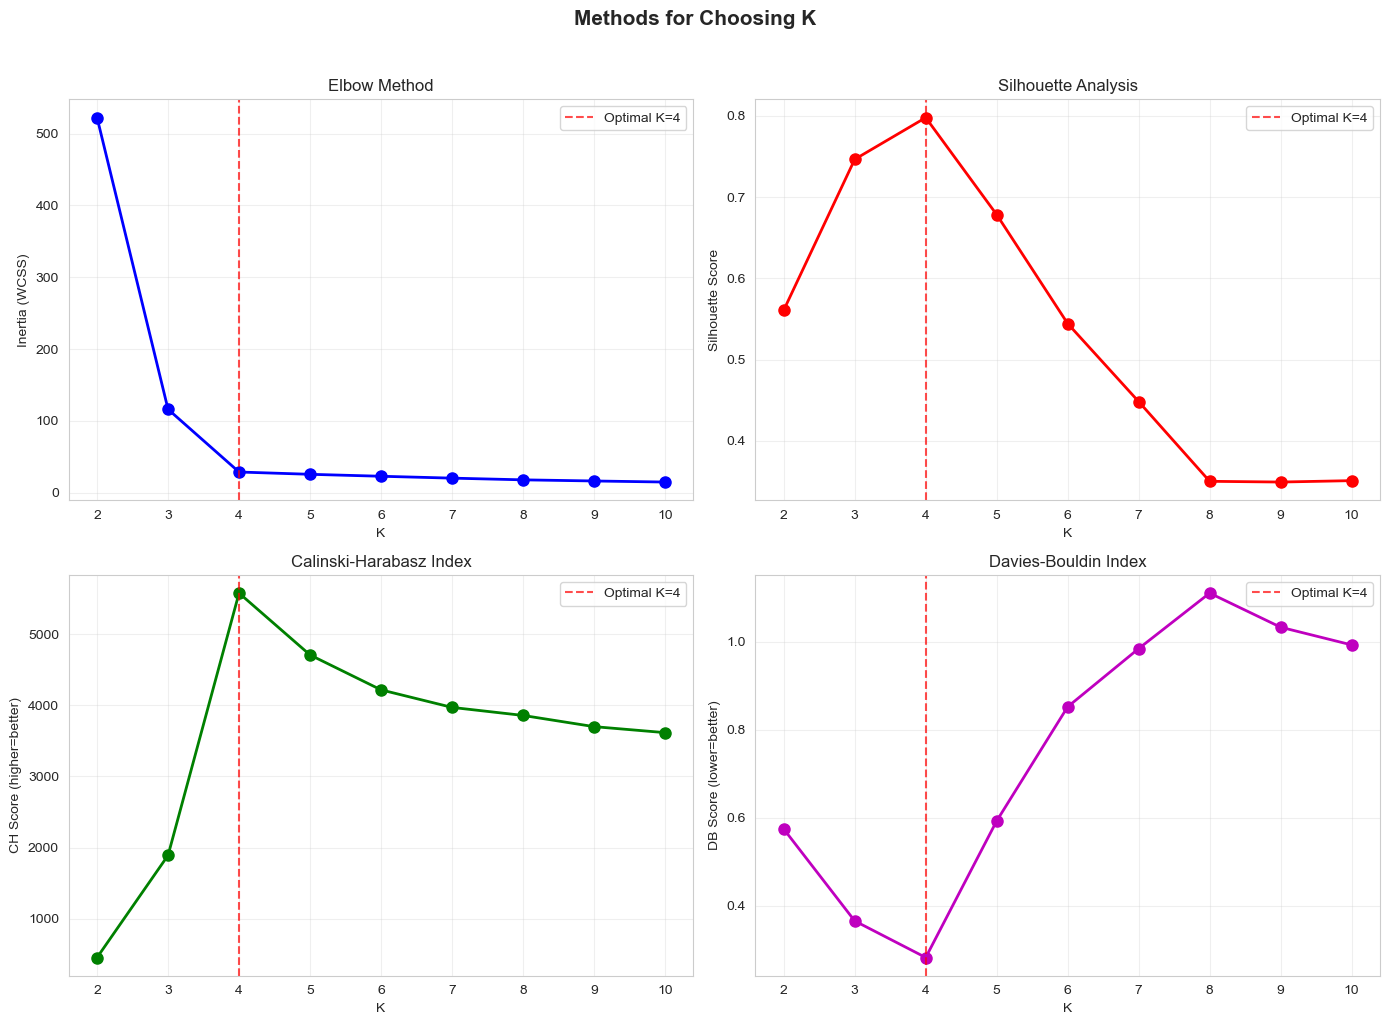

In [5]:

# Elbow Method + Silhouette Score
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

K_range = range(2, 11)
inertias = []
sil_scores = []
ch_scores = []
db_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0,0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
axes[0,0].set(xlabel='K', ylabel='Inertia (WCSS)', title='Elbow Method')
axes[0,0].legend()

axes[0,1].plot(K_range, sil_scores, 'ro-', linewidth=2, markersize=8)
axes[0,1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
axes[0,1].set(xlabel='K', ylabel='Silhouette Score', title='Silhouette Analysis')
axes[0,1].legend()

axes[1,0].plot(K_range, ch_scores, 'go-', linewidth=2, markersize=8)
axes[1,0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
axes[1,0].set(xlabel='K', ylabel='CH Score (higher=better)', title='Calinski-Harabasz Index')
axes[1,0].legend()

axes[1,1].plot(K_range, db_scores, 'mo-', linewidth=2, markersize=8)
axes[1,1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Optimal K=4')
axes[1,1].set(xlabel='K', ylabel='DB Score (lower=better)', title='Davies-Bouldin Index')
axes[1,1].legend()

plt.suptitle('Methods for Choosing K', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 
Silhouette Plot (detailed per-cluster analysis)

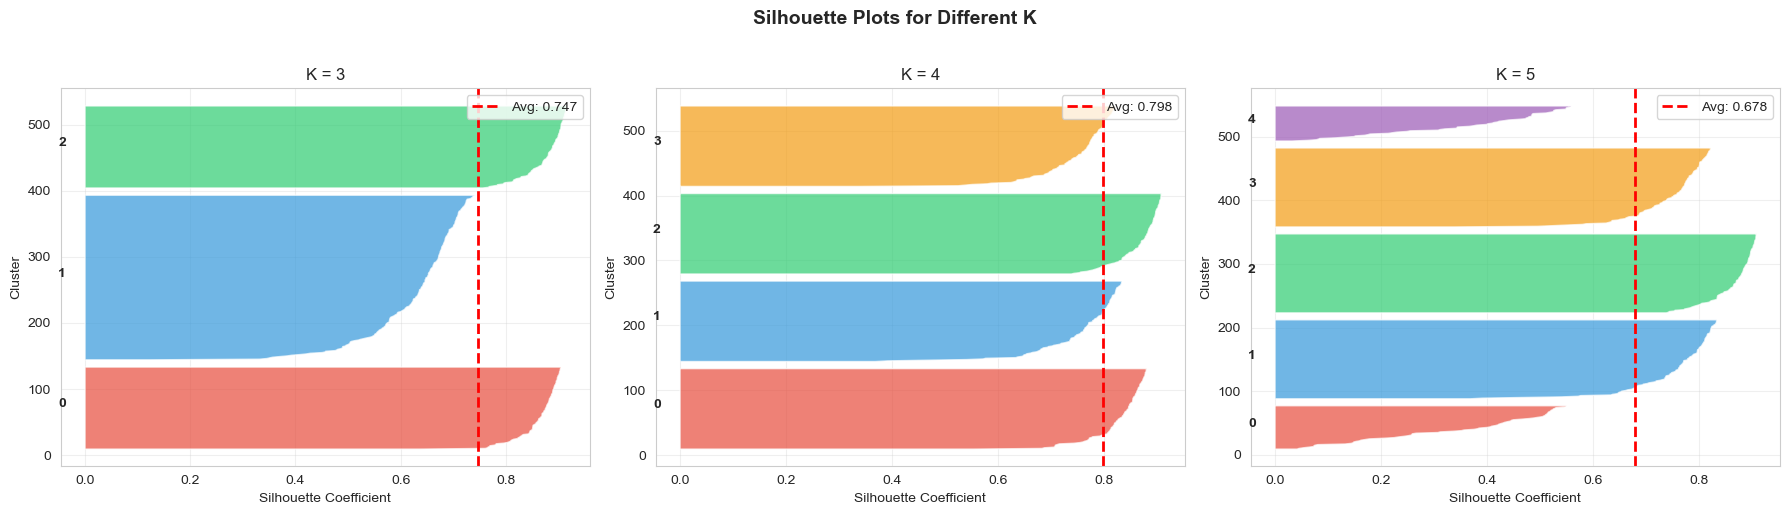

In [6]:
# Detailed Silhouette Plot
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, k in enumerate([3, 4, 5]):
    ax = axes[idx]
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_vals = silhouette_samples(X_scaled, labels)
    avg_score = silhouette_score(X_scaled, labels)
    
    y_lower = 10
    for i in range(k):
        cluster_sil = np.sort(sil_vals[labels == i])
        size = cluster_sil.shape[0]
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                         facecolor=COLORS[i], alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontweight='bold')
        y_lower = y_upper + 10
    
    ax.axvline(x=avg_score, color='red', linestyle='--', linewidth=2,
               label=f'Avg: {avg_score:.3f}')
    ax.set(xlabel='Silhouette Coefficient', ylabel='Cluster', title=f'K = {k}')
    ax.legend(loc='upper right')

plt.suptitle('Silhouette Plots for Different K', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Hierarchical Clustering

### Agglomerative (Bottom-Up)
1. Start with each point as its own cluster
2. Merge the two closest clusters
3. Repeat until one cluster remains
4. Cut the dendrogram at desired height

### Linkage Criteria

| Linkage | Distance $d(A, B)$ | Properties |
|---------|------|------------|
| **Single** | $\min_{a \in A, b \in B} d(a,b)$ | Can find non-convex; prone to chaining |
| **Complete** | $\max_{a \in A, b \in B} d(a,b)$ | Compact clusters; sensitive to outliers |
| **Average** (UPGMA) | $\frac{1}{|A||B|} \sum_{a,b} d(a,b)$ | Balanced compromise |
| **Ward** | $\Delta(A,B) = \frac{|A||B|}{|A|+|B|} \|\bar{A} - \bar{B}\|^2$ | Minimizes variance increase; most popular |

### Complexity
- **Naive:** $O(n^3)$
- **With priority queue:** $O(n^2 \log n)$
- **Space:** $O(n^2)$ (distance matrix)

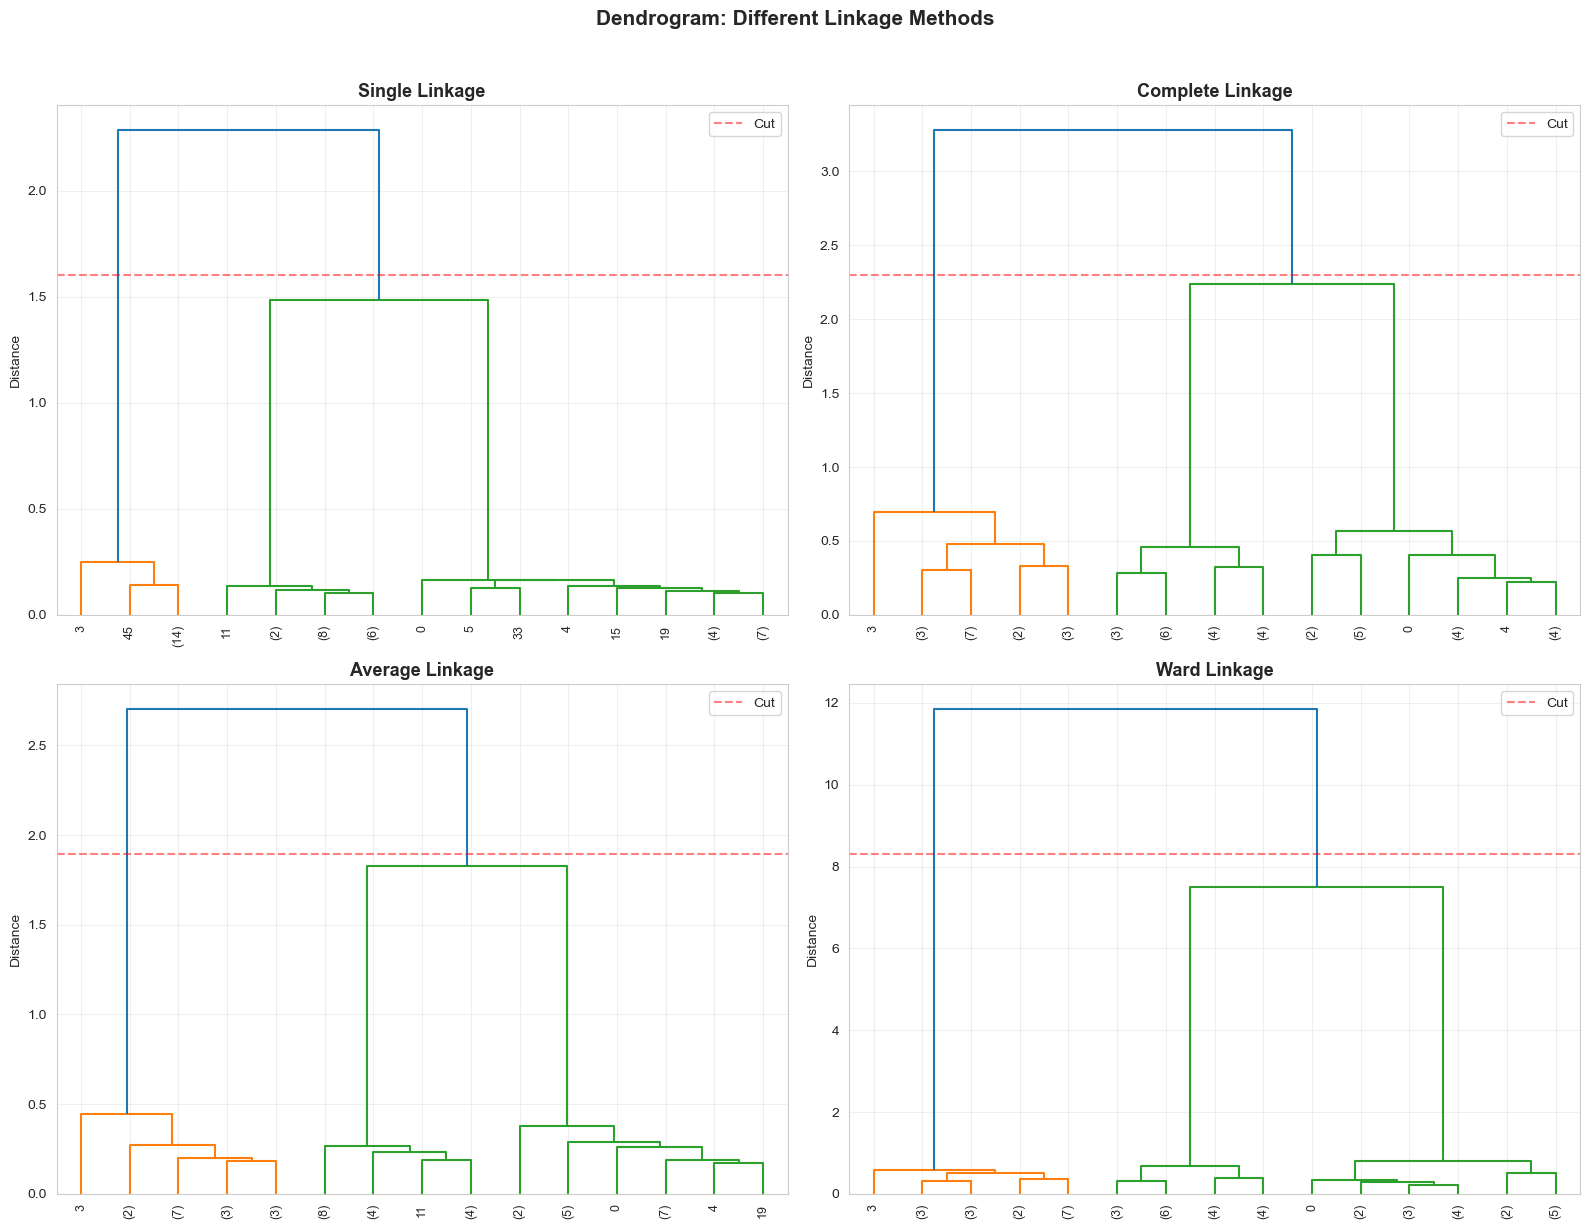

In [7]:
# Hierarchical Clustering with Dendrogram
X, y_true = make_blobs(n_samples=50, centers=3, cluster_std=0.8, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

linkage_methods = ['single', 'complete', 'average', 'ward']

for ax, method in zip(axes.flatten(), linkage_methods):
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=15,
               leaf_rotation=90, leaf_font_size=9,
               color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'{method.capitalize()} Linkage', fontweight='bold', fontsize=13)
    ax.set_ylabel('Distance')
    ax.axhline(y=0.7 * max(Z[:, 2]), color='red', linestyle='--', alpha=0.5, label='Cut')
    ax.legend()

plt.suptitle('Dendrogram: Different Linkage Methods', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

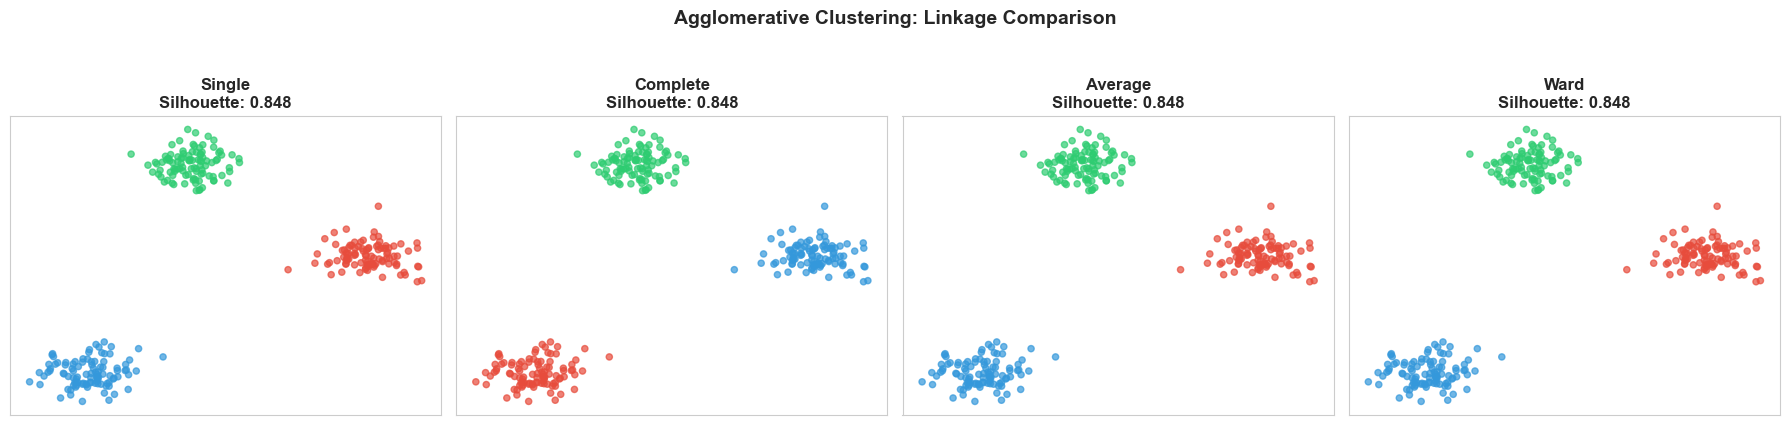

In [8]:
# Compare linkage results on 2D data
X, y_true = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, method in zip(axes, ['single', 'complete', 'average', 'ward']):
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=[COLORS[i] for i in labels], s=20, alpha=0.7)
    ax.set_title(f'{method.capitalize()}\nSilhouette: {sil:.3f}', fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Agglomerative Clustering: Linkage Comparison', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 6. DBSCAN

**Density-Based Spatial Clustering of Applications with Noise**

### Parameters
- **ε (eps):** Radius of neighborhood
- **MinPts (min_samples):** Minimum points to form a dense region

### Point Classification
- **Core Point:** Has $\geq$ MinPts within its $\varepsilon$-neighborhood
- **Border Point:** Within $\varepsilon$ of a core point but has $<$ MinPts neighbors
- **Noise Point:** Not within $\varepsilon$ of any core point

### Algorithm
1. For each unvisited point $p$:
   - Find all points within $\varepsilon$-neighborhood
   - If $|N_\varepsilon(p)| \geq$ MinPts → $p$ is a **core point**, start a cluster
   - Expand cluster by recursively adding density-reachable points
2. Points not in any cluster → **noise**

### Properties
- ✅ No need to specify K
- ✅ Finds arbitrary-shaped clusters
- ✅ Robust to outliers (detects noise)
- ❌ Struggles with varying densities
- ❌ Sensitive to ε and MinPts
- ❌ Not fully deterministic (border points)

### Complexity
- $O(n \log n)$ with KD-tree/Ball-tree
- $O(n^2)$ worst case

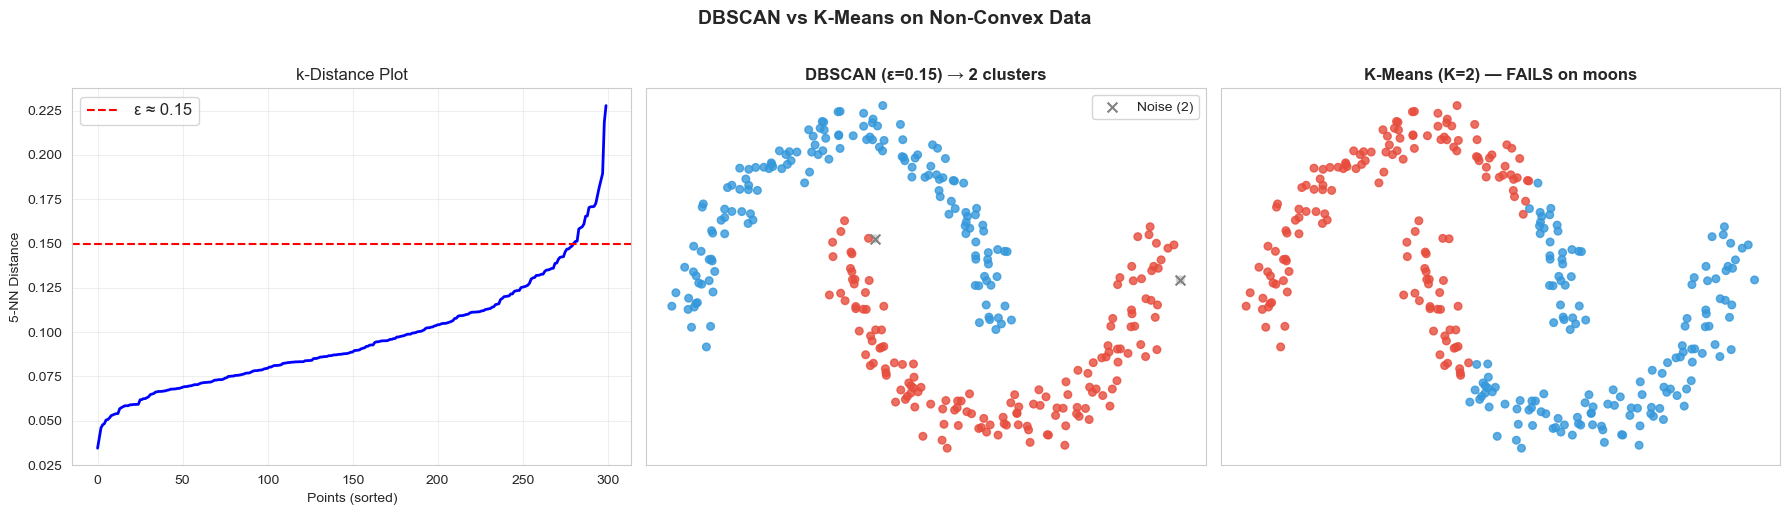

In [9]:
# DBSCAN: Choosing eps with k-distance plot
X_moons, y_moons = make_moons(n_samples=300, noise=0.07, random_state=42)

# k-distance plot
k = 5
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_moons)
distances, _ = nn.kneighbors(X_moons)
k_distances = np.sort(distances[:, -1])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# k-distance plot
axes[0].plot(k_distances, 'b-', linewidth=2)
axes[0].axhline(y=0.15, color='red', linestyle='--', label='ε ≈ 0.15')
axes[0].set(xlabel='Points (sorted)', ylabel=f'{k}-NN Distance', title='k-Distance Plot')
axes[0].legend(fontsize=12)

# DBSCAN with good eps
db = DBSCAN(eps=0.15, min_samples=5)
labels = db.fit_predict(X_moons)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = (labels == -1).sum()

c = [COLORS[l] if l >= 0 else '#cccccc' for l in labels]
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=c, s=30, alpha=0.8)
axes[1].scatter(X_moons[labels == -1, 0], X_moons[labels == -1, 1],
               c='gray', s=50, marker='x', label=f'Noise ({n_noise})', zorder=5)
axes[1].set_title(f'DBSCAN (ε=0.15) → {n_clusters} clusters', fontweight='bold')
axes[1].legend()

# K-Means fails here
km_labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_moons)
axes[2].scatter(X_moons[:, 0], X_moons[:, 1], c=[COLORS[i] for i in km_labels], s=30, alpha=0.8)
axes[2].set_title('K-Means (K=2) — FAILS on moons', fontweight='bold')

for ax in axes[1:]:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('DBSCAN vs K-Means on Non-Convex Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

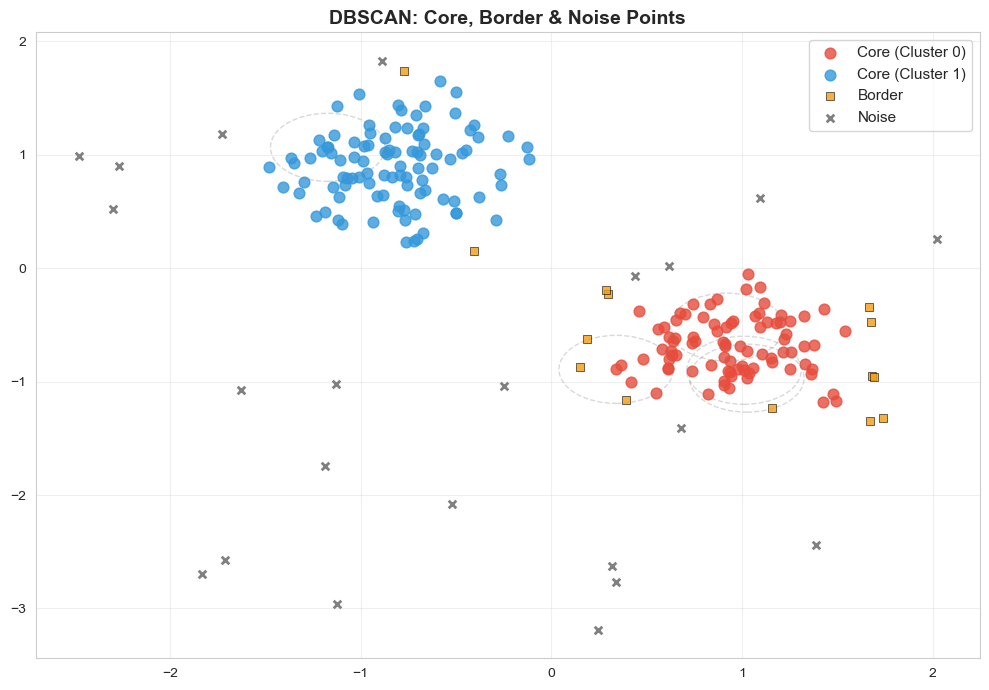

In [10]:
# DBSCAN: Visualize Core, Border, and Noise points
X, y_true = make_blobs(n_samples=200, centers=2, cluster_std=1.5, random_state=42)
# Add noise
noise = np.random.RandomState(42).uniform(-10, 10, (20, 2))
X_noisy = np.vstack([X, noise])
X_noisy_scaled = StandardScaler().fit_transform(X_noisy)

db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X_noisy_scaled)

# Identify core samples
core_mask = np.zeros(len(X_noisy_scaled), dtype=bool)
core_mask[db.core_sample_indices_] = True
noise_mask = labels == -1
border_mask = ~core_mask & ~noise_mask

fig, ax = plt.subplots(figsize=(10, 7))

# Core points
for k in set(labels[labels >= 0]):
    mask = (labels == k) & core_mask
    ax.scatter(X_noisy_scaled[mask, 0], X_noisy_scaled[mask, 1],
              c=COLORS[k], s=60, alpha=0.8, label=f'Core (Cluster {k})')

# Border points
ax.scatter(X_noisy_scaled[border_mask, 0], X_noisy_scaled[border_mask, 1],
          c='#F39C12', s=40, alpha=0.8, marker='s', edgecolors='black',
          linewidths=0.5, label='Border', zorder=4)

# Noise
ax.scatter(X_noisy_scaled[noise_mask, 0], X_noisy_scaled[noise_mask, 1],
          c='gray', s=30, marker='x', linewidths=2, label='Noise', zorder=5)

# Draw epsilon circles for a few core points
for idx in db.core_sample_indices_[:5]:
    circle = plt.Circle(X_noisy_scaled[idx], 0.3, fill=False, color='gray',
                        linestyle='--', alpha=0.3)
    ax.add_patch(circle)

ax.legend(fontsize=11, loc='upper right')
ax.set_title('DBSCAN: Core, Border & Noise Points', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 7. Gaussian Mixture Models (GMM)

### Model

Data is generated from a mixture of $K$ Gaussian distributions:

$$p(x) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x | \mu_k, \Sigma_k)$$

where $\pi_k$ are mixing coefficients ($\sum \pi_k = 1$), $\mu_k$ are means, $\Sigma_k$ are covariance matrices.

### EM Algorithm

**E-step (Expectation):** Compute posterior responsibility

$$r_{ik} = \frac{\pi_k \cdot \mathcal{N}(x_i | \mu_k, \Sigma_k)}{\sum_{j=1}^K \pi_j \cdot \mathcal{N}(x_i | \mu_j, \Sigma_j)}$$

**M-step (Maximization):**

$$N_k = \sum_i r_{ik}, \quad \mu_k = \frac{1}{N_k}\sum_i r_{ik} x_i, \quad \Sigma_k = \frac{1}{N_k}\sum_i r_{ik}(x_i - \mu_k)(x_i - \mu_k)^T, \quad \pi_k = \frac{N_k}{N}$$

### Covariance Types

| Type | Parameters per component | Shape |
|------|------------------------|-------|
| `spherical` | 1 (scalar) | Sphere |
| `diag` | $d$ | Axis-aligned ellipse |
| `tied` | $d(d+1)/2$ (shared) | Same ellipse shape |
| `full` | $d(d+1)/2$ | Arbitrary ellipse |

### Model Selection: BIC and AIC

$$\text{BIC} = -2 \ln \hat{L} + p \ln n \quad \text{(lower is better)}$$
$$\text{AIC} = -2 \ln \hat{L} + 2p$$

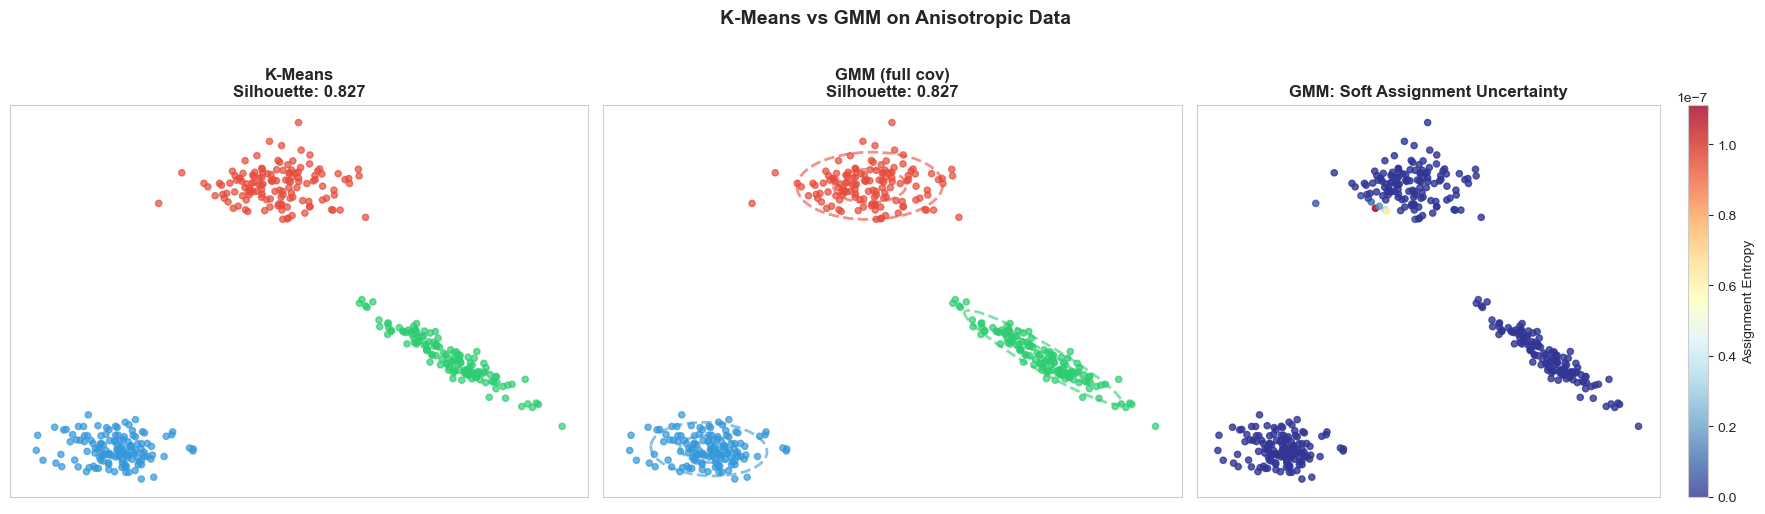

In [11]:
# GMM: Soft clustering with ellipsoidal clusters
X, y_true = make_blobs(n_samples=400, centers=3, cluster_std=[1.0, 1.5, 0.8], random_state=42)
# Stretch one cluster
X[y_true == 1] = X[y_true == 1] @ np.array([[0.6, -0.6], [-0.4, 0.8]])
X_scaled = StandardScaler().fit_transform(X)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)
axes[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=[COLORS[i] for i in km_labels], s=20, alpha=0.7)
axes[0].set_title(f'K-Means\nSilhouette: {silhouette_score(X_scaled, km_labels):.3f}', fontweight='bold')

# GMM
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42, n_init=5)
gmm_labels = gmm.fit_predict(X_scaled)
axes[1].scatter(X_scaled[:, 0], X_scaled[:, 1], c=[COLORS[i] for i in gmm_labels], s=20, alpha=0.7)

# Draw covariance ellipses
from matplotlib.patches import Ellipse
for k in range(3):
    mean = gmm.means_[k]
    cov = gmm.covariances_[k]
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    for n_std in [1, 2]:
        ell = Ellipse(mean, 2*n_std*np.sqrt(eigenvalues[0]), 2*n_std*np.sqrt(eigenvalues[1]),
                     angle=angle, fill=False, color=COLORS[k], linewidth=2, linestyle='--', alpha=0.6)
        axes[1].add_patch(ell)
axes[1].set_title(f'GMM (full cov)\nSilhouette: {silhouette_score(X_scaled, gmm_labels):.3f}', fontweight='bold')

# Soft probabilities
probs = gmm.predict_proba(X_scaled)
entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
sc = axes[2].scatter(X_scaled[:, 0], X_scaled[:, 1], c=entropy, cmap='RdYlBu_r', s=20, alpha=0.8)
plt.colorbar(sc, ax=axes[2], label='Assignment Entropy')
axes[2].set_title('GMM: Soft Assignment Uncertainty', fontweight='bold')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('K-Means vs GMM on Anisotropic Data', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

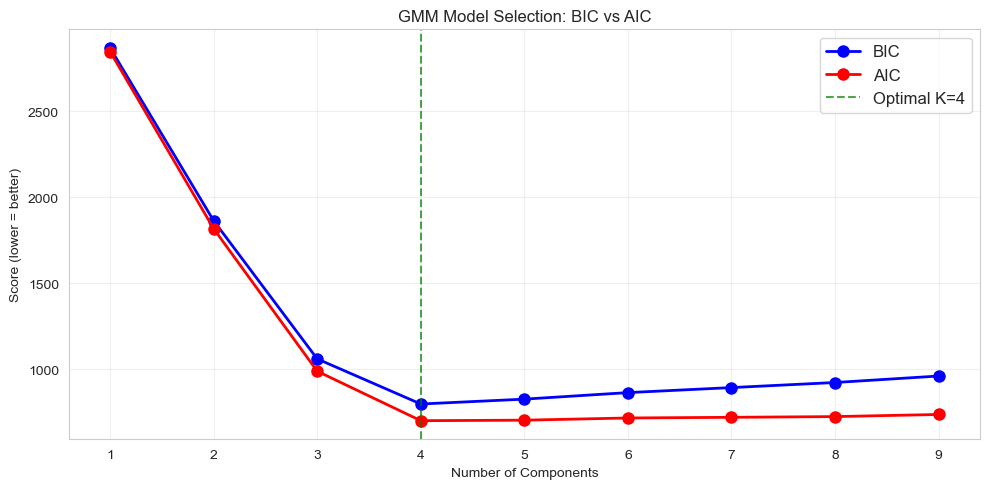

BIC optimal K: 4
AIC optimal K: 4


In [12]:
# GMM: BIC/AIC for model selection
X, _ = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

n_range = range(1, 10)
bics, aics = [], []

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_range, bics, 'bo-', linewidth=2, label='BIC', markersize=8)
ax.plot(n_range, aics, 'ro-', linewidth=2, label='AIC', markersize=8)
ax.axvline(x=4, color='green', linestyle='--', alpha=0.7, label='Optimal K=4')
ax.set(xlabel='Number of Components', ylabel='Score (lower = better)',
       title='GMM Model Selection: BIC vs AIC')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f'BIC optimal K: {np.argmin(bics) + 1}')
print(f'AIC optimal K: {np.argmin(aics) + 1}')

---
## 8. Spectral Clustering

### Idea
1. Build a **similarity graph** (e.g., k-NN graph or RBF kernel)
2. Compute the **graph Laplacian** $L = D - W$ (or normalized versions)
3. Find the **first $K$ eigenvectors** of $L$
4. Embed data in spectral space and run **K-Means**

### Math

**Unnormalized Laplacian:**
$$L = D - W$$

**Normalized (Shi-Malik):**
$$L_{rw} = D^{-1}L = I - D^{-1}W$$

**Normalized (Ng-Jordan-Weiss):**
$$L_{sym} = D^{-1/2} L D^{-1/2} = I - D^{-1/2} W D^{-1/2}$$

### Properties
- ✅ Captures **connectivity**, not compactness
- ✅ Works for non-convex shapes
- ❌ $O(n^3)$ eigendecomposition
- ❌ Still needs K

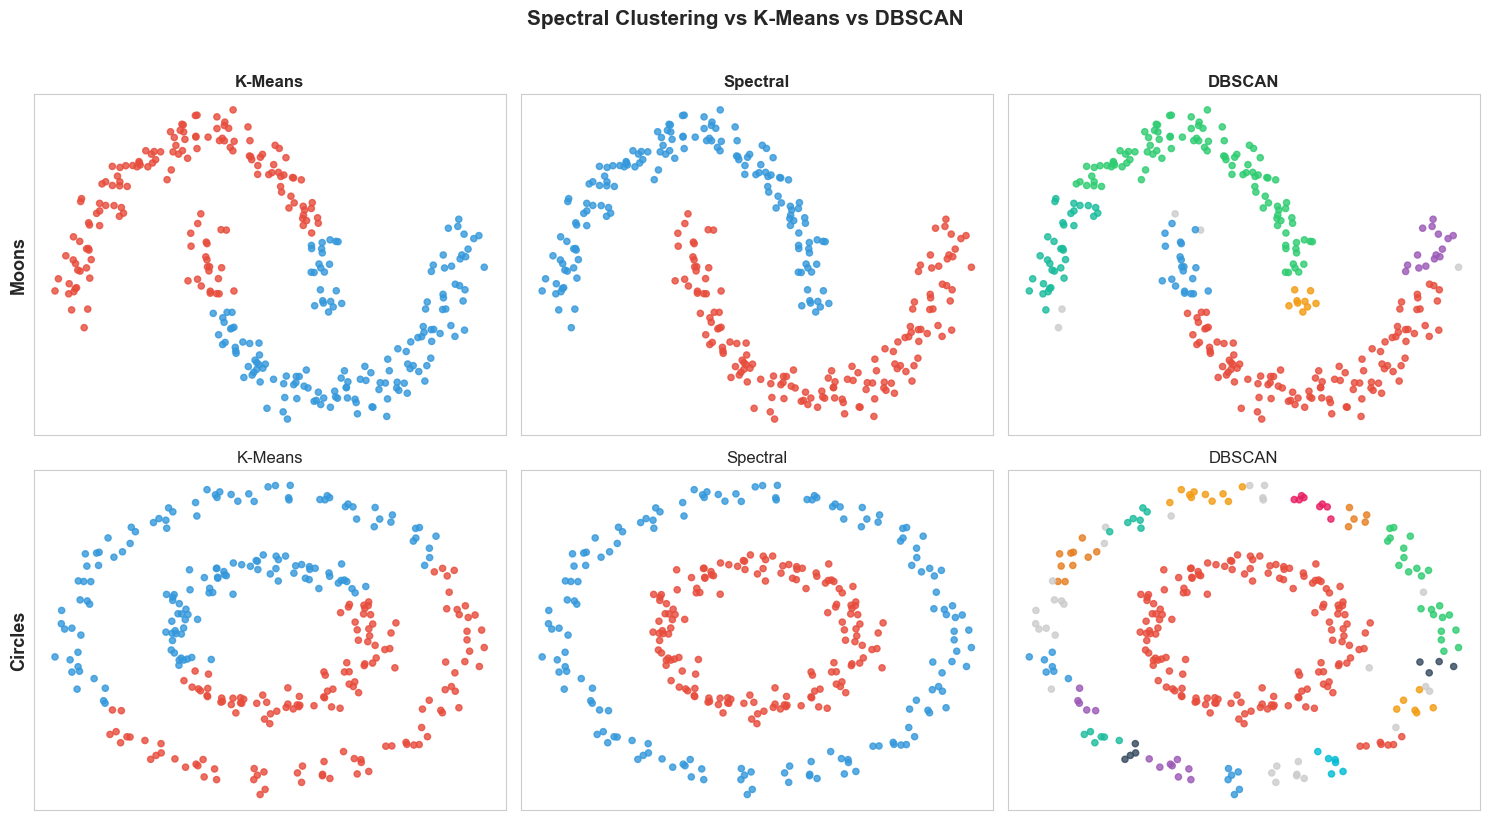

In [13]:
# Spectral Clustering excels at non-convex shapes
datasets = [
    ('Moons', *make_moons(300, noise=0.07, random_state=42)),
    ('Circles', *make_circles(300, noise=0.05, factor=0.5, random_state=42)),
]

algorithms = [
    ('K-Means', lambda X: KMeans(2, random_state=42, n_init=10).fit_predict(X)),
    ('Spectral', lambda X: SpectralClustering(2, affinity='nearest_neighbors',
                                              n_neighbors=10, random_state=42).fit_predict(X)),
    ('DBSCAN', lambda X: DBSCAN(eps=0.2, min_samples=5).fit_predict(X)),
]

fig, axes = plt.subplots(len(datasets), len(algorithms), figsize=(15, 8))

for i, (name, X, y) in enumerate(datasets):
    X = StandardScaler().fit_transform(X)
    for j, (alg_name, alg_func) in enumerate(algorithms):
        ax = axes[i][j]
        labels = alg_func(X)
        # c = [COLORS[l] if l >= 0 else '#ccc' for l in labels]
        c = [COLORS[l % len(COLORS)] if l >= 0 else '#ccc' for l in labels]
        ax.scatter(X[:, 0], X[:, 1], c=c, s=20, alpha=0.8)
        ax.set_title(f'{alg_name}', fontweight='bold' if i == 0 else 'normal')
        if j == 0:
            ax.set_ylabel(name, fontsize=13, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Spectral Clustering vs K-Means vs DBSCAN', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 9. Evaluation Metrics

### External Metrics (ground truth available)

| Metric | Range | Formula / Description |
|--------|-------|----------------------|
| **Adjusted Rand Index** | [-1, 1] | Measures pairwise agreement, adjusted for chance. 1 = perfect |
| **Normalized Mutual Info** | [0, 1] | $\text{NMI} = \frac{2 \cdot I(Y;C)}{H(Y) + H(C)}$ |
| **V-Measure** | [0, 1] | Harmonic mean of homogeneity and completeness |
| **Fowlkes-Mallows** | [0, 1] | Geometric mean of precision and recall of pairs |

### Internal Metrics (no ground truth)

| Metric | Range | Optimal |
|--------|-------|--------|
| **Silhouette Score** | [-1, 1] | Higher = better. $s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$ |
| **Davies-Bouldin** | [0, ∞) | Lower = better. Avg similarity between each cluster and its most similar |
| **Calinski-Harabasz** | [0, ∞) | Higher = better. Ratio of between/within cluster dispersion |
| **Inertia (WCSS)** | [0, ∞) | Lower = better (but always decreases with K) |

> **Interview Tip:** Always mention that internal metrics have biases — e.g., silhouette favors convex clusters, so it may mislead for DBSCAN results.

In [14]:
# Compare all metrics across algorithms
X, y_true = make_blobs(n_samples=500, centers=4, cluster_std=1.0, random_state=42)
X_scaled = StandardScaler().fit_transform(X)

results = {}
algorithms = {
    'K-Means (K=4)': KMeans(4, random_state=42, n_init=10).fit_predict(X_scaled),
    'K-Means (K=3)': KMeans(3, random_state=42, n_init=10).fit_predict(X_scaled),
    'K-Means (K=6)': KMeans(6, random_state=42, n_init=10).fit_predict(X_scaled),
    'Agglom. (Ward)': AgglomerativeClustering(4, linkage='ward').fit_predict(X_scaled),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5).fit_predict(X_scaled),
    'GMM': GaussianMixture(4, random_state=42).fit_predict(X_scaled),
}

print(f'{"Algorithm":<20} {"ARI":>8} {"NMI":>8} {"Silh":>8} {"DB":>8} {"CH":>10}')
print('=' * 64)

for name, labels in algorithms.items():
    # Filter out noise for metrics that don't handle -1
    mask = labels >= 0
    n_clusters = len(set(labels[mask]))
    
    if n_clusters < 2:
        print(f'{name:<20} {"N/A":>8} {"N/A":>8} {"N/A":>8} {"N/A":>8} {"N/A":>10}')
        continue
    
    ari = adjusted_rand_score(y_true, labels)
    nmi = normalized_mutual_info_score(y_true, labels)
    sil = silhouette_score(X_scaled[mask], labels[mask])
    db = davies_bouldin_score(X_scaled[mask], labels[mask])
    ch = calinski_harabasz_score(X_scaled[mask], labels[mask])
    
    print(f'{name:<20} {ari:>8.3f} {nmi:>8.3f} {sil:>8.3f} {db:>8.3f} {ch:>10.1f}')

Algorithm                 ARI      NMI     Silh       DB         CH
K-Means (K=4)           1.000    1.000    0.798    0.282     5578.0
K-Means (K=3)           0.713    0.857    0.747    0.365     1892.0
K-Means (K=6)           0.821    0.890    0.544    0.852     4218.0
Agglom. (Ward)          1.000    1.000    0.798    0.282     5578.0
DBSCAN                  0.713    0.857    0.747    0.365     1892.0
GMM                     1.000    1.000    0.798    0.282     5578.0



---
## 10. Algorithm Comparison

| Property | K-Means | Hierarchical | DBSCAN | GMM | Spectral |
|----------|---------|-------------|--------|-----|----------|
| **Specify K?** | Yes | Cut height | No | Yes | Yes |
| **Cluster shape** | Spherical | Flexible | Arbitrary | Ellipsoidal | Arbitrary |
| **Handles noise?** | No | No | Yes | Partially | No |
| **Soft assignment?** | No | No | No | Yes | No |
| **Scalability** | ★★★★★ | ★★ | ★★★ | ★★★ | ★★ |
| **Complexity** | $O(nKdI)$ | $O(n^2\log n)$ | $O(n\log n)$ | $O(nKd^2I)$ | $O(n^3)$ |
| **Deterministic?** | No | Yes | Yes* | No | No |
| **Best for** | Large, spherical | Small data, dendrograms | Noise, arbitrary shapes | Ellipsoidal, soft | Non-convex, graphs |

*DBSCAN: core point assignments are deterministic; border points may vary.

### Decision Flowchart
1. **Know K?** → If no and want noise detection → DBSCAN / HDBSCAN
2. **Spherical clusters?** → Yes → K-Means; No → GMM, Spectral, or DBSCAN
3. **Need probabilities?** → GMM
4. **Large dataset?** → K-Means or Mini-Batch K-Means
5. **Non-convex shapes?** → Spectral Clustering or DBSCAN
6. **Need hierarchy?** → Agglomerative

---
## 11. Challenging Datasets & Edge Cases

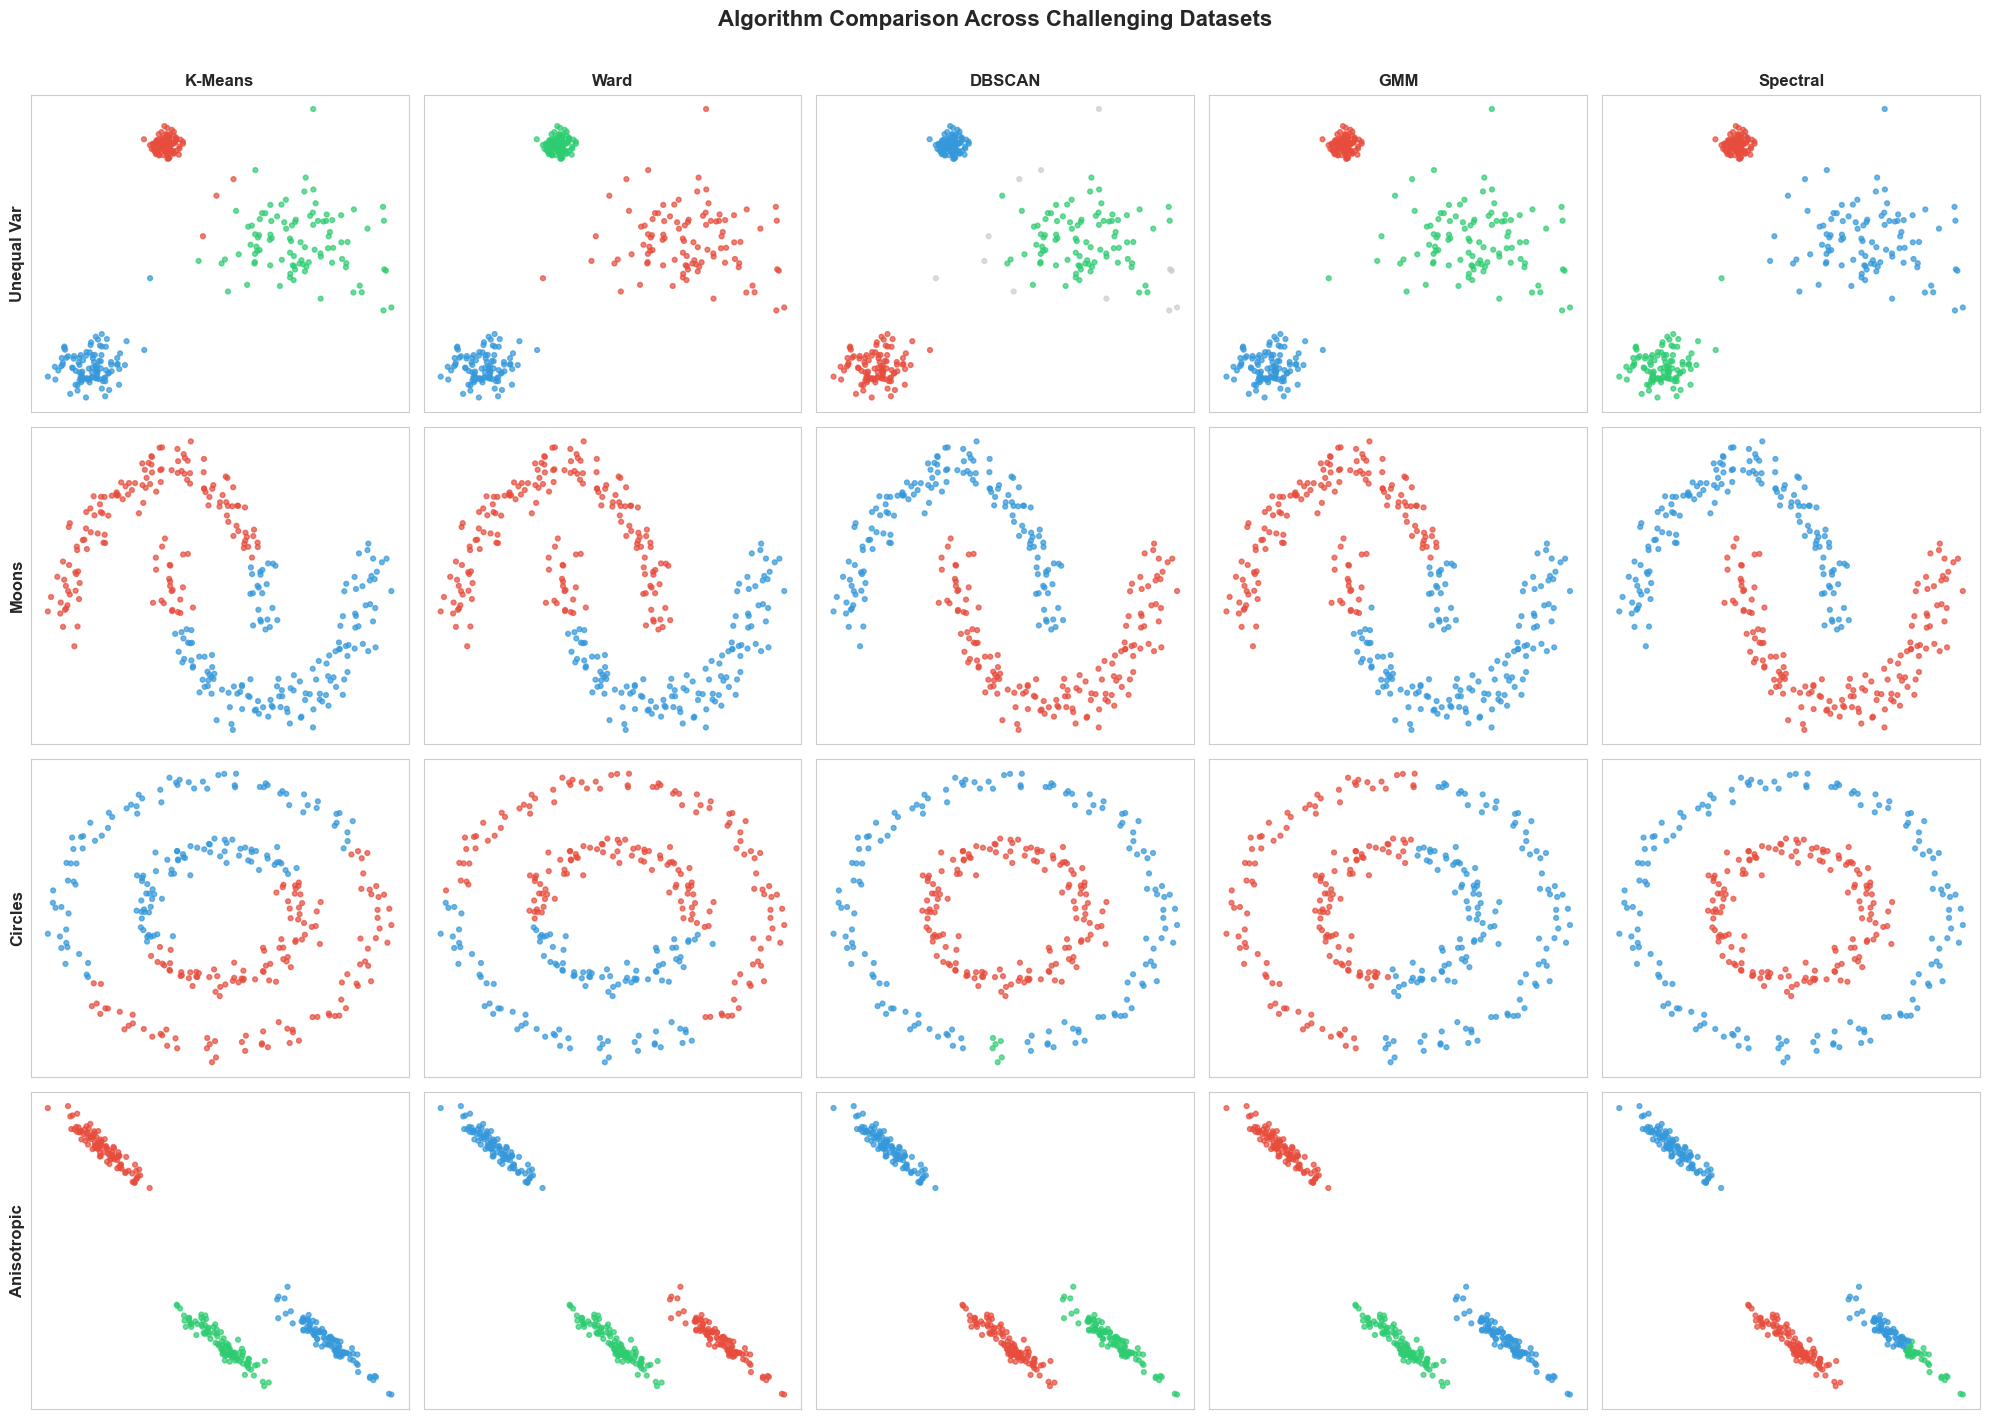

In [15]:
# Side-by-side comparison on 4 challenging datasets
np.random.seed(42)

# Dataset 1: Unequal variance blobs
X1, y1 = make_blobs(300, centers=3, cluster_std=[0.5, 2.5, 1.0], random_state=42)

# Dataset 2: Moons
X2, y2 = make_moons(300, noise=0.08, random_state=42)

# Dataset 3: Concentric circles
X3, y3 = make_circles(300, noise=0.05, factor=0.5, random_state=42)

# Dataset 4: Anisotropic
X4_raw, y4 = make_blobs(300, centers=3, cluster_std=1.0, random_state=42)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X4 = np.dot(X4_raw, transformation)

datasets = [
    ('Unequal Var', X1, 3),
    ('Moons', X2, 2),
    ('Circles', X3, 2),
    ('Anisotropic', X4, 3),
]

alg_names = ['K-Means', 'Ward', 'DBSCAN', 'GMM', 'Spectral']

fig, axes = plt.subplots(len(datasets), len(alg_names), figsize=(20, 14))

for i, (dname, X, k) in enumerate(datasets):
    Xs = StandardScaler().fit_transform(X)
    
    preds = [
        KMeans(k, random_state=42, n_init=10).fit_predict(Xs),
        AgglomerativeClustering(k, linkage='ward').fit_predict(Xs),
        DBSCAN(eps=0.3, min_samples=5).fit_predict(Xs),
        GaussianMixture(k, random_state=42).fit_predict(Xs),
        SpectralClustering(k, affinity='nearest_neighbors', n_neighbors=10, random_state=42).fit_predict(Xs),
    ]
    
    for j, (aname, labels) in enumerate(zip(alg_names, preds)):
        ax = axes[i][j]
        c = [COLORS[l] if l >= 0 else '#ccc' for l in labels]
        ax.scatter(Xs[:, 0], Xs[:, 1], c=c, s=12, alpha=0.7)
        if i == 0:
            ax.set_title(aname, fontweight='bold', fontsize=12)
        if j == 0:
            ax.set_ylabel(dname, fontsize=12, fontweight='bold')
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Algorithm Comparison Across Challenging Datasets',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 12. Interview Questions & Answers

### Q1: What is the difference between K-Means and K-Medoids?

**K-Means** uses the **mean** of cluster points as the centroid. **K-Medoids** (PAM) uses an **actual data point** (medoid) as the cluster center. K-Medoids is more robust to outliers since it minimizes the sum of dissimilarities rather than squared Euclidean distances, but it's computationally more expensive — $O(n^2 K)$ per iteration.

---

### Q2: How do you handle categorical features?

- **K-Modes** for purely categorical data (uses mode + Hamming distance)
- **K-Prototypes** for mixed types
- **One-hot encoding + K-Means** (beware curse of dimensionality)
- **Gower distance + Hierarchical** clustering
- **Embedding approaches** (autoencoders → K-Means)

---

### Q3: Why scale features before K-Means?

K-Means uses **Euclidean distance**, which is dominated by features with larger scales. A feature ranging 0–1000 will dominate one ranging 0–1, regardless of their importance. Use `StandardScaler` (zero mean, unit variance) or `MinMaxScaler`.

---

### Q4: Hard vs Soft clustering?

- **Hard** (K-Means, DBSCAN): Each point → exactly one cluster
- **Soft** (GMM, Fuzzy C-Means): Each point → probability distribution over clusters
- Soft clustering is useful when points lie between clusters or you need uncertainty estimates

---

### Q5: When DBSCAN over K-Means?

Choose **DBSCAN** when: (1) you don't know K, (2) clusters are non-convex (rings, spirals), (3) data has noise/outliers, (4) you don't want to assume spherical clusters. But note DBSCAN struggles with **varying densities** → use **HDBSCAN** instead.

---

### Q6: Curse of dimensionality in clustering?

In high dimensions, all pairwise distances converge → distance metrics become meaningless. Solutions:
- **PCA / UMAP / t-SNE** for dimensionality reduction before clustering
- Feature selection
- Subspace clustering
- Spectral clustering (more robust)

---

### Q7: How does GMM relate to K-Means?

K-Means is a **special case of GMM** where:
- All covariances = $\sigma^2 I$ (spherical, equal)
- Hard assignments (argmax) instead of soft (posterior probabilities)
- As $\sigma \to 0$, EM converges to K-Means

---

### Q8: What is the Silhouette Score?

For each point $i$:
$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

- $a(i)$ = avg distance to same-cluster points (cohesion)
- $b(i)$ = avg distance to nearest different cluster (separation)
- Range: $[-1, 1]$. Near +1 = well-clustered, near 0 = boundary, near -1 = misclassified
- ⚠️ Biased toward convex clusters

---

### Q9: Mini-Batch K-Means?

Uses **random subsets** (mini-batches) in each iteration instead of the full dataset. Trades off some quality for massive speed improvement. Converges faster but to a slightly worse solution. Use for datasets too large to fit in memory.

---

### Q10: How to cluster time series?

- **DTW** (Dynamic Time Warping) distance + K-Medoids
- Feature extraction (statistics, FFT coefficients) + standard clustering
- **K-Shape** (shape-based, cross-correlation)
- Deep learning embeddings (autoencoders, temporal transformers) + K-Means
- Choice depends on: shape vs. feature similarity, temporal alignment needs

---

### Q11: What is HDBSCAN and why is it better?

HDBSCAN = Hierarchical DBSCAN. It builds a hierarchy of density-based clusters and extracts the most stable clusters. **Advantages over DBSCAN:**
- Handles **varying densities** (the biggest DBSCAN weakness)
- Only one main parameter (`min_cluster_size`)
- More robust, less sensitive to parameter choice
- Provides cluster stability scores

---

### Q12: What preprocessing steps for clustering?

1. **Handle missing values** (impute or remove)
2. **Feature scaling** (StandardScaler or MinMaxScaler — critical!)
3. **Dimensionality reduction** if high-dimensional (PCA, UMAP)
4. **Outlier detection** (may want to remove before K-Means)
5. **Feature engineering** (domain-specific transformations)
6. **Encode categoricals** appropriately

---

## 🎉 Summary Cheat Sheet

```
┌─────────────────────────────────────────────────────────────┐
│                  CLUSTERING CHEAT SHEET                     │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│  K-Means: J = Σ Σ ‖x - μk‖²    O(nKdI)   Spherical       │
│  GMM:     p(x) = Σ πk·N(μk,Σk)  O(nKd²I)  Ellipsoidal    │
│  DBSCAN:  eps + MinPts           O(n log n) Arbitrary      │
│  Hierarch: Linkage criteria      O(n²log n) Flexible       │
│  Spectral: Graph Laplacian       O(n³)      Non-convex     │
│                                                             │
│  ALWAYS:  1) Scale features  2) Try multiple K             │
│           3) Use multiple metrics  4) Visualize!           │
│                                                             │
│  Metrics: Silhouette [-1,1]↑  DB [0,∞)↓  CH [0,∞)↑       │
│           ARI [-1,1]↑         NMI [0,1]↑                  │
└─────────────────────────────────────────────────────────────┘
```

**Good luck with your interviews! 🚀**